In [1]:
# # HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения
#
# **Датасет:** EMNIST (split='balanced')
# **Цель:** Исследовать влияние регуляризации (Dropout, BatchNorm, EarlyStopping) и параметров оптимизации (LR, optimizer, weight decay) на качество модели.

In [2]:
# ## 1. Импорты и общие настройки


import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import pandas as pd
import json
from dataclasses import dataclass

In [3]:
# ## 2. Воспроизводимость и устройство


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


In [4]:
# ## 3. Данные: EMNIST (split='balanced')

os.makedirs("artifacts", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)

print(f"classes: {len(train_full.classes)}")  # 47 классов
print(f"train size: {len(train_full)}")
print(f"test size: {len(test_ds)}")

classes: 47
train size: 112800
test size: 18800


In [5]:
# ## 4. Разбиение train/val и DataLoader


BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print(f"x_batch: {x_batch.shape} {x_batch.dtype}")
print(f"y_batch: {y_batch.shape} {y_batch.dtype}")

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [6]:
# ## 5. Модель MLP


class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,  # 47 классов в EMNIST balanced
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [7]:
# ## 6. Вспомогательные функции


def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 9,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} |  "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} |  "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f} "
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}.  "
                        f"Лучший val_acc={early_stopping.best_score:.4f} "
                    )
                early_stopping.restore_best(model)
                break

    return history


In [8]:
# ## 7. Часть A (S08): Регуляризация (E1-E4)


# E1: Baseline (без регуляризации)
set_seed(42)
model_e1 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e1.parameters(), lr=1e-3)
history_e1 = fit(model_e1, train_loader, val_loader, optimizer, criterion, device)
test_loss_e1, test_acc_e1 = evaluate(model_e1, test_loader, criterion, device)
print(f"E1 Baseline test: loss={test_loss_e1:.4f}, acc={test_acc_e1:.4f}")


# E2: Dropout
set_seed(42)
model_e2 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)
optimizer = optim.Adam(model_e2.parameters(), lr=1e-3)
history_e2 = fit(model_e2, train_loader, val_loader, optimizer, criterion, device)
test_loss_e2, test_acc_e2 = evaluate(model_e2, test_loader, criterion, device)
print(f"E2 Dropout test: loss={test_loss_e2:.4f}, acc={test_acc_e2:.4f}")


# E3: BatchNorm
set_seed(42)
model_e3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizer = optim.Adam(model_e3.parameters(), lr=1e-3)
history_e3 = fit(model_e3, train_loader, val_loader, optimizer, criterion, device)
test_loss_e3, test_acc_e3 = evaluate(model_e3, test_loader, criterion, device)
print(f"E3 BatchNorm test: loss={test_loss_e3:.4f}, acc={test_acc_e3:.4f}")


# E4: Dropout + BatchNorm + EarlyStopping
set_seed(42)
model_e4 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=True).to(device)
optimizer = optim.Adam(model_e4.parameters(), lr=1e-3)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_e4 = fit(model_e4, train_loader, val_loader, optimizer, criterion, device, epochs = 18, early_stopping=es)
test_loss_e4, test_acc_e4 = evaluate(model_e4, test_loader, criterion, device)
print(f"E4 Combo test: loss={test_loss_e4:.4f}, acc={test_acc_e4:.4f}")

# Сохранение лучшей модели
torch.save(model_e4.state_dict(), "artifacts/best_model.pt")

epoch 01/9 |  train loss=1.1378, acc=0.6634 |  val loss=0.7388, acc=0.7724 
epoch 02/9 |  train loss=0.6580, acc=0.7882 |  val loss=0.6219, acc=0.7998 
epoch 03/9 |  train loss=0.5598, acc=0.8124 |  val loss=0.5612, acc=0.8182 
epoch 04/9 |  train loss=0.5080, acc=0.8261 |  val loss=0.5528, acc=0.8182 
epoch 05/9 |  train loss=0.4729, acc=0.8358 |  val loss=0.5287, acc=0.8290 
epoch 06/9 |  train loss=0.4462, acc=0.8448 |  val loss=0.5235, acc=0.8334 
epoch 07/9 |  train loss=0.4244, acc=0.8492 |  val loss=0.5316, acc=0.8292 
epoch 08/9 |  train loss=0.4072, acc=0.8541 |  val loss=0.5397, acc=0.8252 
epoch 09/9 |  train loss=0.3950, acc=0.8568 |  val loss=0.4965, acc=0.8385 
E1 Baseline test: loss=0.5312, acc=0.8309
epoch 01/9 |  train loss=1.5230, acc=0.5530 |  val loss=0.8577, acc=0.7402 
epoch 02/9 |  train loss=1.0369, acc=0.6794 |  val loss=0.7313, acc=0.7680 
epoch 03/9 |  train loss=0.9370, acc=0.7030 |  val loss=0.6681, acc=0.7865 
epoch 04/9 |  train loss=0.8918, acc=0.7209 | 


= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
Experiment O1: Adam lr=0.1


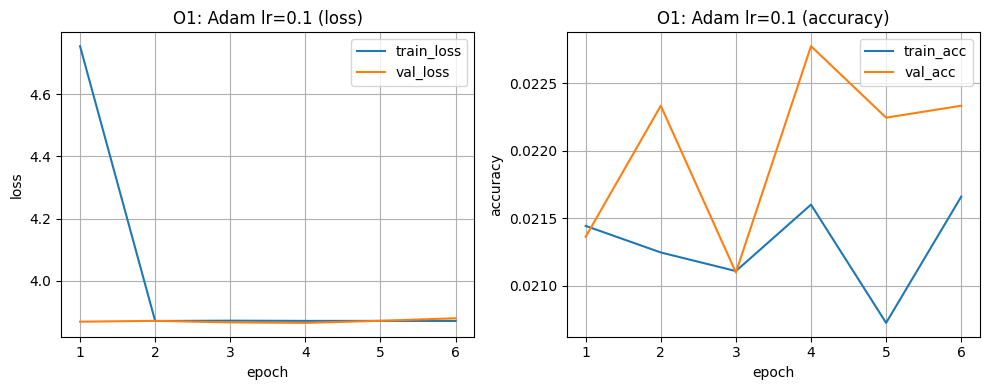


= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
Experiment O2: Adam lr=1e-5


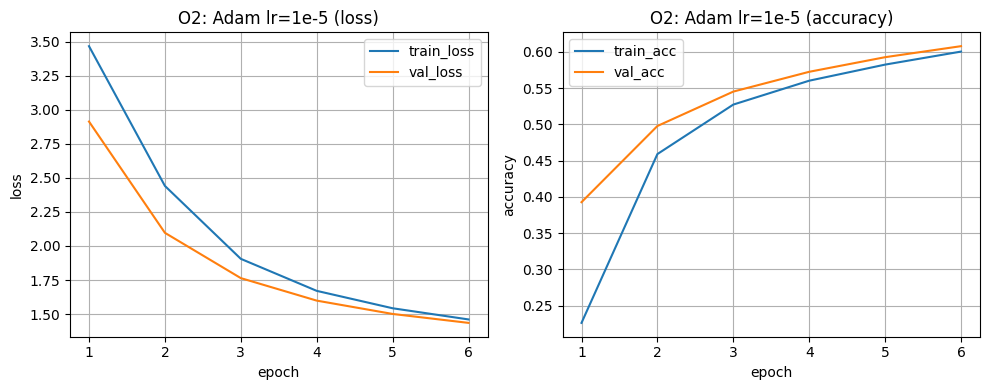


= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
Experiment O3: SGD lr=0.1 momentum=0.9


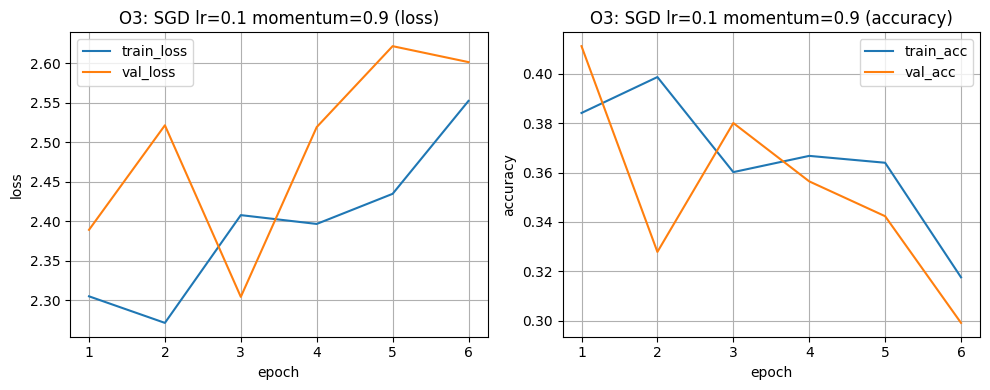

In [14]:
# ## 8. Часть B (S09): LR, оптимизаторы, weight decay (O1-O3)


def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=6):
    model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

    if optimizer_kind == "adam":
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_kind == "sgd":
        opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    history = fit(model, train_loader, val_loader, opt, criterion, device, epochs=epochs, verbose=False)

    best_val_acc = float(np.nanmax(history["val_acc"])) if len(history["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(history["val_loss"])) if len(history["val_loss"]) else float("nan")

    return {
        "experiment_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind == "sgd" else None,
        "epochs_ran": len(history["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": history,
    }


# O1: LR слишком большой
print("\n" + "= "*80)
print("Experiment O1: Adam lr=0.1")
res_o1 = run_experiment(exp_id="O1", optimizer_kind="adam", lr=0.1)
plot_history(res_o1["history"], title="O1: Adam lr=0.1")


# O2: LR слишком маленький
print("\n" + "= "*80)
print("Experiment O2: Adam lr=1e-5")
res_o2 = run_experiment(exp_id="O2", optimizer_kind="adam", lr=1e-5)
plot_history(res_o2["history"], title="O2: Adam lr=1e-5")


# O3: SGD+momentum
print("\n" + "= "*80)
print("Experiment O3: SGD lr=0.1 momentum=0.9")
res_o3 = run_experiment(exp_id="O3", optimizer_kind="sgd", lr=0.1, momentum=0.9)
plot_history(res_o3["history"], title="O3: SGD lr=0.1 momentum=0.9")




In [15]:
# Сохранение результатов
os.makedirs("artifacts/figures", exist_ok=True)

# Метаданные для отчета
DATASET_NAME = "EMNIST(split='balanced')"
SEED = 42
MODEL_SUMMARY_BASE = "MLP (256, 128); ReLU"

# Таблица результатов Part A
# Добавляем отсутствующие колонки: dataset, seed, model_summary, epochs_trained, best_val_accuracy
results_a = [
    {
        "experiment_id": "E1", 
        "dataset": DATASET_NAME, 
        "seed": SEED,
        "model_summary": f"{MODEL_SUMMARY_BASE}; Dropout(0.0); BatchNorm(False)",
        "epochs_trained": len(history_e1["val_acc"]),
        "best_val_accuracy": float(np.max(history_e1["val_acc"])),
        "test_acc": test_acc_e1, 
        "test_loss": test_loss_e1
    },
    {
        "experiment_id": "E2", 
        "dataset": DATASET_NAME, 
        "seed": SEED,
        "model_summary": f"{MODEL_SUMMARY_BASE}; Dropout(0.3); BatchNorm(False)",
        "epochs_trained": len(history_e2["val_acc"]),
        "best_val_accuracy": float(np.max(history_e2["val_acc"])),
        "test_acc": test_acc_e2, 
        "test_loss": test_loss_e2
    },
    {
        "experiment_id": "E3", 
        "dataset": DATASET_NAME, 
        "seed": SEED,
        "model_summary": f"{MODEL_SUMMARY_BASE}; Dropout(0.0); BatchNorm(True)",
        "epochs_trained": len(history_e3["val_acc"]),
        "best_val_accuracy": float(np.max(history_e3["val_acc"])),
        "test_acc": test_acc_e3, 
        "test_loss": test_loss_e3
    },
    {
        "experiment_id": "E4", 
        "dataset": DATASET_NAME, 
        "seed": SEED,
        "model_summary": f"{MODEL_SUMMARY_BASE}; Dropout(0.3); BatchNorm(True)",
        "epochs_trained": len(history_e4["val_acc"]),
        "best_val_accuracy": float(np.max(history_e4["val_acc"])),
        "test_acc": test_acc_e4, 
        "test_loss": test_loss_e4
    },
]

# Таблица результатов Part B
# Добавляем отсутствующие колонки: dataset, seed, model_summary. 
# Переименовываем epochs_ran -> epochs_trained, best_val_acc -> best_val_accuracy для единообразия
results_b = []
for r in [res_o1, res_o2, res_o3]:
    entry = {k: v for k, v in r.items() if k != "history"}
    entry["dataset"] = DATASET_NAME
    entry["seed"] = SEED
    entry["model_summary"] = f"{MODEL_SUMMARY_BASE}" # Базовая модель для экспериментов оптимизации
    entry["epochs_trained"] = entry.pop("epochs_ran")
    entry["best_val_accuracy"] = entry.pop("best_val_acc")
    results_b.append(entry)

df_a = pd.DataFrame(results_a)
df_a.to_csv("artifacts/runs_partA.csv", index=False)

df_b = pd.DataFrame(results_b)
df_b.to_csv("artifacts/runs_partB.csv", index=False)

# Объединенная таблица
all_results = results_a + results_b
df_all = pd.DataFrame(all_results)
df_all.to_csv("artifacts/runs.csv", index=False)

# Конфиг лучшей модели
best_config = {
    "experiment": "E4",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": f"{MODEL_SUMMARY_BASE}; Dropout(0.3); BatchNorm(True)",
    "optimizer": "Adam",
    "lr": 0.001,
    "weight_decay": 0.0,
    "epochs_trained": len(history_e4["val_acc"]),
    "best_val_accuracy": float(np.max(history_e4["val_acc"])),
    "best_val_loss": float(np.min(history_e4["val_loss"])),
    "test_accuracy": test_acc_e4,
    "test_loss": test_loss_e4,
}

with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

# Графики
plt.figure(figsize=(10, 4))
plt.plot(history_e4["train_loss"], label="train_loss")
plt.plot(history_e4["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Лучший эксперимент (E4) - loss")
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/curves_best.png", dpi=150)
plt.close()

# Графики LR extremes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(res_o1["history"]["val_loss"], label="O1: lr=0.1", color="red")
axes[0].plot(res_o2["history"]["val_loss"], label="O2: lr=1e-5", color="blue")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("val_loss")
axes[0].set_title("Сравнение LR (val_loss)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(res_o1["history"]["val_acc"], label="O1: lr=0.1", color="red")
axes[1].plot(res_o2["history"]["val_acc"], label="O2: lr=1e-5", color="blue")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val_acc")
axes[1].set_title("Сравнение LR (val_acc)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=150)
plt.close()

print("\n Все артефакты сохранены в artifacts/")


 Все артефакты сохранены в artifacts/


In [16]:
# ## 9. Итоговая таблица результатов


print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
print(df_all.to_string(index=False))


ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
experiment_id                  dataset  seed                                        model_summary  epochs_trained  best_val_accuracy  test_acc  test_loss optimizer      lr  weight_decay  momentum  best_val_loss
           E1 EMNIST(split='balanced')    42 MLP (256, 128); ReLU; Dropout(0.0); BatchNorm(False)               9           0.838453  0.830889   0.531215       NaN     NaN           NaN       NaN            NaN
           E2 EMNIST(split='balanced')    42 MLP (256, 128); ReLU; Dropout(0.3); BatchNorm(False)               9           0.812235  0.805697   0.588235       NaN     NaN           NaN       NaN            NaN
           E3 EMNIST(split='balanced')    42  MLP (256, 128); ReLU; Dropout(0.0); BatchNorm(True)               9           0.852754  0.842793   0.472278       NaN     NaN           NaN       NaN            NaN
           E4 EMNIST(split='balanced')    42  MLP (256, 128); ReLU; Dropout(0.3); BatchNorm(True)              18           0.